# Full Training Pipeline: Physics-AI Phase Recovery

This notebook gives you a complete starter pipeline for phase recovery from intensity-only measurements.

## Contents
1. Imports and reproducibility
2. Synthetic physics data generation
3. Optional Gerchberg-Saxton baseline
4. PyTorch dataset and model
5. Training loop
6. Evaluation
7. Failure modes and fixes


In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)


DEVICE: cpu


## Problem setup

We simulate a hidden complex field

\[
E(t)=A(t)e^{i\phi(t)}
\]

and measure only the magnitudes of two dispersed versions of that field.


In [2]:
@dataclass
class SimConfig:
    n_samples: int = 1024
    t_min: float = -5.0
    t_max: float = 5.0
    disp1: float = 0.8
    disp2: float = 1.5
    amp_sigma_min: float = 0.45
    amp_sigma_max: float = 1.2
    chirp2_min: float = -1.5
    chirp2_max: float = 2.5
    ripple_amp_min: float = 0.0
    ripple_amp_max: float = 0.5
    ripple_freq_min: float = 0.5
    ripple_freq_max: float = 2.5
    phase_offset_min: float = -math.pi
    phase_offset_max: float = math.pi
    noise_std: float = 0.01

CFG = SimConfig()

def make_time_axis(cfg):
    t = torch.linspace(cfg.t_min, cfg.t_max, cfg.n_samples)
    dt = float(t[1] - t[0])
    return t, dt

def fftfreq_torch(n, dt):
    return 2 * math.pi * torch.fft.fftfreq(n, d=dt)

def disperse_signal(E_t, dt, beta2z):
    w = fftfreq_torch(E_t.shape[-1], dt).to(E_t.device)
    H = torch.exp(-0.5j * beta2z * w**2)
    E_w = torch.fft.fft(E_t, dim=-1)
    return torch.fft.ifft(E_w * H, dim=-1)

def synthesize_field(t, cfg):
    sigma = torch.empty(1).uniform_(cfg.amp_sigma_min, cfg.amp_sigma_max).item()
    chirp2 = torch.empty(1).uniform_(cfg.chirp2_min, cfg.chirp2_max).item()
    ripple_amp = torch.empty(1).uniform_(cfg.ripple_amp_min, cfg.ripple_amp_max).item()
    ripple_freq = torch.empty(1).uniform_(cfg.ripple_freq_min, cfg.ripple_freq_max).item()
    phase_offset = torch.empty(1).uniform_(cfg.phase_offset_min, cfg.phase_offset_max).item()

    amp = torch.exp(-0.5 * (t / sigma)**2)
    phase = chirp2 * t**2 + ripple_amp * torch.sin(ripple_freq * t) + phase_offset
    E = amp * torch.exp(1j * phase)
    return E, amp, phase


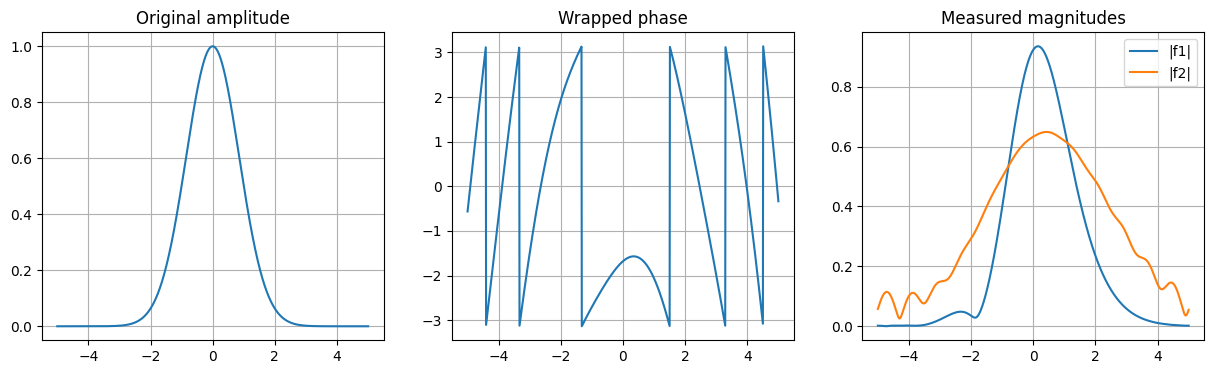

In [3]:
t, dt = make_time_axis(CFG)
E, amp, phase = synthesize_field(t, CFG)
obs1 = disperse_signal(E, dt, CFG.disp1)
obs2 = disperse_signal(E, dt, CFG.disp2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t.numpy(), torch.abs(E).numpy())
ax[0].set_title("Original amplitude")
ax[0].grid(True)

ax[1].plot(t.numpy(), torch.angle(E).numpy())
ax[1].set_title("Wrapped phase")
ax[1].grid(True)

ax[2].plot(t.numpy(), torch.abs(obs1).numpy(), label="|f1|")
ax[2].plot(t.numpy(), torch.abs(obs2).numpy(), label="|f2|")
ax[2].set_title("Measured magnitudes")
ax[2].legend()
ax[2].grid(True)
plt.show()


## Dataset generation

In [4]:
class PhaseRecoveryDataset(Dataset):
    def __init__(self, n_examples, cfg):
        self.cfg = cfg
        self.t, self.dt = make_time_axis(cfg)

        xs, ys, amps, Es = [], [], [], []
        for _ in range(n_examples):
            E, amp, phase = synthesize_field(self.t, cfg)
            f1 = disperse_signal(E, self.dt, cfg.disp1)
            f2 = disperse_signal(E, self.dt, cfg.disp2)

            mag1 = torch.abs(f1)
            mag2 = torch.abs(f2)

            if cfg.noise_std > 0:
                mag1 = torch.clamp(mag1 + cfg.noise_std * torch.randn_like(mag1), min=0.0)
                mag2 = torch.clamp(mag2 + cfg.noise_std * torch.randn_like(mag2), min=0.0)

            x = torch.cat([mag1, mag2], dim=0)
            y = torch.unwrap(torch.angle(E), dim=0)

            xs.append(x)
            ys.append(y)
            amps.append(amp)
            Es.append(E)

        self.x = torch.stack(xs)
        self.y = torch.stack(ys)
        self.amp = torch.stack(amps)
        self.E = torch.stack(Es)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "phase": self.y[idx],
            "amp": self.amp[idx],
            "E": self.E[idx],
        }

N_TOTAL = 2400
dataset = PhaseRecoveryDataset(N_TOTAL, CFG)

n_train = int(0.8 * N_TOTAL)
n_val = int(0.1 * N_TOTAL)
n_test = N_TOTAL - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(7)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))


AttributeError: module 'torch' has no attribute 'unwrap'

## Optional Gerchberg-Saxton baseline

In [ ]:
def temporal_gs_recover(mag1, mag2, dt, disp1, disp2, n_iter=30, seed=7):
    torch.manual_seed(seed)
    n = mag1.numel()
    phase0 = 2 * math.pi * torch.rand(n) - math.pi
    E1 = mag1 * torch.exp(1j * phase0)
    hist = []

    for _ in range(n_iter):
        E0 = disperse_signal(E1, dt, -disp1)
        E2 = disperse_signal(E0, dt, disp2)
        E2 = mag2 * torch.exp(1j * torch.angle(E2))

        E0b = disperse_signal(E2, dt, -disp2)
        E1b = disperse_signal(E0b, dt, disp1)

        err = torch.mean((torch.abs(E1b) - mag1) ** 2).item()
        hist.append(err)
        E1 = mag1 * torch.exp(1j * torch.angle(E1b))

    E0_final = disperse_signal(E1, dt, -disp1)
    return E0_final, hist

sample = dataset[0]
gs_rec, gs_hist = temporal_gs_recover(
    sample["x"][:CFG.n_samples],
    sample["x"][CFG.n_samples:],
    dt,
    CFG.disp1,
    CFG.disp2,
    n_iter=30
)

plt.figure(figsize=(8, 3))
plt.plot(gs_hist)
plt.title("GS baseline error history")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## Model

In [ ]:
class PhaseNet(nn.Module):
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, n_out),
        )

    def forward(self, x):
        return self.net(x)

model = PhaseNet(2 * CFG.n_samples, CFG.n_samples).to(DEVICE)
print("parameters:", sum(p.numel() for p in model.parameters()))


## Losses and evaluation

In [ ]:
def phase_mse(pred_phase, true_phase):
    return torch.mean((pred_phase - true_phase) ** 2)

def complex_field_loss(pred_phase, true_phase, amp):
    pred_E = amp * torch.exp(1j * pred_phase)
    true_E = amp * torch.exp(1j * true_phase)
    return torch.mean(torch.abs(pred_E - true_E) ** 2)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_phase = 0.0
    total_complex = 0.0
    n = 0

    for batch in loader:
        x = batch["x"].to(DEVICE)
        phase = batch["phase"].to(DEVICE)
        amp = batch["amp"].to(DEVICE)

        pred = model(x)
        l1 = phase_mse(pred, phase)
        l2 = complex_field_loss(pred, phase, amp)

        bs = x.shape[0]
        total_phase += l1.item() * bs
        total_complex += l2.item() * bs
        n += bs

    return {"phase_mse": total_phase / n, "complex_mse": total_complex / n}


## Training loop

In [ ]:
EPOCHS = 20
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {
    "train_phase": [],
    "train_complex": [],
    "val_phase": [],
    "val_complex": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_phase = 0.0
    running_complex = 0.0
    n = 0

    for batch in train_loader:
        x = batch["x"].to(DEVICE)
        phase = batch["phase"].to(DEVICE)
        amp = batch["amp"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)

        loss_phase = phase_mse(pred, phase)
        loss_complex = complex_field_loss(pred, phase, amp)
        loss = loss_phase + 0.5 * loss_complex

        loss.backward()
        optimizer.step()

        bs = x.shape[0]
        running_phase += loss_phase.item() * bs
        running_complex += loss_complex.item() * bs
        n += bs

    train_phase = running_phase / n
    train_complex = running_complex / n
    val_metrics = evaluate(model, val_loader)

    history["train_phase"].append(train_phase)
    history["train_complex"].append(train_complex)
    history["val_phase"].append(val_metrics["phase_mse"])
    history["val_complex"].append(val_metrics["complex_mse"])

    print(
        f"epoch {epoch+1:02d} | "
        f"train phase {train_phase:.5f} | "
        f"train complex {train_complex:.5f} | "
        f"val phase {val_metrics['phase_mse']:.5f} | "
        f"val complex {val_metrics['complex_mse']:.5f}"
    )


In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history["train_phase"], label="train phase mse")
plt.plot(history["val_phase"], label="val phase mse")
plt.plot(history["train_complex"], label="train complex mse")
plt.plot(history["val_complex"], label="val complex mse")
plt.title("Training curves")
plt.xlabel("epoch")
plt.grid(True)
plt.legend()
plt.show()


## Test evaluation

In [ ]:
test_metrics = evaluate(model, test_loader)
print(test_metrics)


## Inspect recovered samples

In [ ]:
@torch.no_grad()
def show_predictions(model, dataset, indices=(0, 25, 100)):
    model.eval()
    fig, ax = plt.subplots(len(indices), 3, figsize=(15, 4 * len(indices)))
    if len(indices) == 1:
        ax = np.expand_dims(ax, axis=0)

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        x = sample["x"].unsqueeze(0).to(DEVICE)
        true_phase = sample["phase"]
        amp = sample["amp"]

        pred_phase = model(x).squeeze(0).cpu()
        pred_E = amp * torch.exp(1j * pred_phase)
        true_E = sample["E"]

        ax[row, 0].plot(t.numpy(), x[0, :CFG.n_samples].cpu().numpy(), label="|f1|")
        ax[row, 0].plot(t.numpy(), x[0, CFG.n_samples:].cpu().numpy(), label="|f2|")
        ax[row, 0].set_title(f"Input traces #{idx}")
        ax[row, 0].grid(True)
        ax[row, 0].legend()

        ax[row, 1].plot(t.numpy(), true_phase.numpy(), label="true phase")
        ax[row, 1].plot(t.numpy(), pred_phase.numpy(), "--", label="pred phase")
        ax[row, 1].set_title("Recovered phase")
        ax[row, 1].grid(True)
        ax[row, 1].legend()

        ax[row, 2].plot(t.numpy(), torch.abs(true_E).numpy(), label="true |E|")
        ax[row, 2].plot(t.numpy(), torch.abs(pred_E).numpy(), "--", label="recon |E|")
        ax[row, 2].set_title("Complex-field magnitude")
        ax[row, 2].grid(True)
        ax[row, 2].legend()

    plt.tight_layout()
    plt.show()

show_predictions(model, dataset, indices=(0, 25, 100))


## Failure modes and fixes

### 1. Loss does not go down
- lower the learning rate
- increase dataset size
- reduce the phase range first

### 2. Validation is much worse than training
- overfitting
- train/test mismatch
- too little noise diversity

### 3. Predicted phase looks shifted
A global phase offset is natural. Compare complex fields or subtract mean phase offset for display.

### 4. GS works but the network fails
- model too small
- not enough training
- labels inconsistent
- dispersed measurements too similar

### 5. Everything fails
Check whether `disp1` and `disp2` are too close and whether the synthetic phase family is too broad.


In [ ]:
@torch.no_grad()
def aligned_phase(pred_phase, true_phase):
    offset = torch.mean(pred_phase - true_phase)
    return pred_phase - offset

sample = dataset[5]
pred = model(sample["x"].unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
aligned = aligned_phase(pred, sample["phase"])

plt.figure(figsize=(10,4))
plt.plot(t.numpy(), sample["phase"].numpy(), label="true")
plt.plot(t.numpy(), pred.numpy(), "--", label="pred raw")
plt.plot(t.numpy(), aligned.numpy(), ":", label="pred aligned")
plt.title("Phase alignment demo")
plt.grid(True)
plt.legend()
plt.show()


## Next upgrades
- predict amplitude and phase together
- use 1D convolutions instead of only linear layers
- benchmark against GS or Hilbert on every batch
- finetune on experimental data
- increase batch size and move fully onto CUDA
